# Notebook 08 — Cluster-Level Psychological Profiles

This notebook analyzes the **psychological composition of the structural population segments** identified earlier in the pipeline.

In previous stages:

- **Notebook 06b** generated structural population clusters using demographic and socioeconomic features from the American Community Survey (ACS).
- **Notebook 07** enriched the ACS population with **probabilistic psychological traits** inferred from the General Social Survey (GSS).

As a result, each individual in the synthetic population now carries both:

- structural attributes and cluster membership  
- probabilistic attitudes and behavioral traits.

The purpose of this notebook is to **aggregate those individual-level probabilities at the cluster level** in order to understand the behavioral character of each structural segment.

---

## Methodological Workflow

### Phase 1 — Load the Enriched Population Dataset
The dataset produced in the previous notebook (`07_mk_structural_attitudes_population_v1.parquet`) is loaded.  
This dataset contains the ACS structural population, cluster assignments, and inferred psychological probabilities.

---

### Phase 2 — Weighted Cluster Aggregation
Psychological probabilities are aggregated by cluster using ACS person weights (`pwgtp`).  
This produces cluster-level estimates for:

- ideology  
- party alignment  
- religiosity  
- life satisfaction  
- media engagement

These estimates represent the **expected attitudinal distribution within each structural segment**.

---

### Phase 3 — Cluster Psychological Profiles
The aggregated distributions are used to construct a psychological profile for each cluster.  
This step reveals how clusters differ in terms of political orientation, religiosity, well-being, and media behavior.

---

### Phase 4 — Comparative Analysis Across Clusters
Clusters are compared across psychological dimensions to identify meaningful behavioral patterns and contrasts between segments.

---

## Outcome

The result of this notebook is a set of **behaviorally interpretable profiles for each structural population segment**.

These profiles transform purely demographic clusters into **proto-personas**, providing insight into how different segments of the population may differ in attitudes, values, and engagement patterns.

This analysis forms the foundation for downstream work on **audience segmentation, messaging strategy, and influence modeling**.

In [1]:
# Phase 1: Imports

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
# Project directories
PROJECT_ROOT = Path().resolve().parent

DATA_DIR   = PROJECT_ROOT / "data"
MODELS_DIR = DATA_DIR / "societal_models"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODELS_DIR  :", MODELS_DIR)

PROJECT_ROOT: /Users/marcomagnolo/Projects/Market_Kinetics
MODELS_DIR  : /Users/marcomagnolo/Projects/Market_Kinetics/data/societal_models


In [3]:
# Load enriched population dataset

input_path = MODELS_DIR / "07_mk_structural_attitudes_population.parquet"

df = pd.read_parquet(input_path)

print("Dataset loaded")
print("Shape:", df.shape)

Dataset loaded
Shape: (778466, 32)


In [4]:
df.head()

,age_bin,sex_label,race_eth,edu_tier,emp_tier,income_tier_fixed,mar_tier,tenure,household_size,vehicle_count,...,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,No_Rent,2,0,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
1,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,No_Rent,4,2,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
2,35-44,Male,Black_NH,HS_or_less,Other_Not_in_Labor_Force,0-19k,Never_Married,Group_Quarters,1,0,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
3,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,Owner,5,2,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
4,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,No_Rent,4,1,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 778466 entries, 0 to 778465
Data columns (total 32 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age_bin                          778466 non-null  string 
 1   sex_label                        778466 non-null  string 
 2   race_eth                         778466 non-null  string 
 3   edu_tier                         778466 non-null  string 
 4   emp_tier                         778466 non-null  str    
 5   income_tier_fixed                778466 non-null  string 
 6   mar_tier                         778466 non-null  string 
 7   tenure                           778466 non-null  str    
 8   household_size                   778466 non-null  int64  
 9   vehicle_count                    778466 non-null  Int64  
 10  household_type                   778466 non-null  str    
 11  serialno                         778466 non-null  str    
 12  sporder      

In [6]:
df.race_eth.value_counts()

race_eth
White_NH    475529
Hispanic    132510
Black_NH     91553
Asian_NH     46401
Other_NH     32473
Name: count, dtype: int64[pyarrow]

In [7]:
# simplify race_eth labels
df["race_eth"] = df["race_eth"].str.replace("_NH", "", regex=False)

df["race_eth"].value_counts()

race_eth
White       475529
Hispanic    132510
Black        91553
Asian        46401
Other        32473
Name: count, dtype: int64[pyarrow]

In [8]:
# Phase 2
# identify psychological probability columns
prob_cols = [c for c in df.columns if "__" in c]

print("Number of probability columns:", len(prob_cols))
print(prob_cols)

Number of probability columns: 17
['ideology__conservative', 'ideology__liberal', 'ideology__moderate', 'party_alignment__democrat', 'party_alignment__independent', 'party_alignment__other', 'party_alignment__republican', 'religiosity__high', 'religiosity__low', 'religiosity__medium', 'religiosity__none', 'life_satisfaction__not_happy', 'life_satisfaction__pretty_happy', 'life_satisfaction__very_happy', 'media_engagement__high', 'media_engagement__low', 'media_engagement__medium']


In [9]:
# group probability columns by dimension
from collections import defaultdict

prob_groups = defaultdict(list)

for col in prob_cols:
    dimension = col.split("__")[0]
    prob_groups[dimension].append(col)

# sort columns within each group for readability
prob_groups = {k: sorted(v) for k, v in prob_groups.items()}

for dim, cols in prob_groups.items():
    print(f"\n{dim}:")
    print(cols)


ideology:
['ideology__conservative', 'ideology__liberal', 'ideology__moderate']

party_alignment:
['party_alignment__democrat', 'party_alignment__independent', 'party_alignment__other', 'party_alignment__republican']

religiosity:
['religiosity__high', 'religiosity__low', 'religiosity__medium', 'religiosity__none']

life_satisfaction:
['life_satisfaction__not_happy', 'life_satisfaction__pretty_happy', 'life_satisfaction__very_happy']

media_engagement:
['media_engagement__high', 'media_engagement__low', 'media_engagement__medium']


In [10]:
# compute weighted psychological profile for each cluster
cluster_psych = (
    df.groupby("cluster")
      .apply(
          lambda g: pd.Series({
              col: np.average(g[col], weights=g["pwgtp"])
              for col in prob_cols
          }),
          include_groups=False
      )
      .reset_index()
)

print("Cluster-level psychological profile shape:", cluster_psych.shape)
cluster_psych.head()

Cluster-level psychological profile shape: (7, 18)


,cluster,ideology__conservative,ideology__liberal,ideology__moderate,party_alignment__democrat,party_alignment__independent,party_alignment__other,party_alignment__republican,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,0,0.296922,0.301277,0.401801,0.460976,0.191375,0.037487,0.310162,0.238104,0.267316,0.242474,0.252107,0.123666,0.573752,0.302582,0.270201,0.643708,0.086091
1,1,0.330637,0.299916,0.369448,0.487787,0.155179,0.028311,0.328723,0.280686,0.294416,0.220146,0.204753,0.123269,0.574700,0.302032,0.325858,0.568254,0.105888
2,2,0.281164,0.319807,0.399028,0.462254,0.217430,0.032938,0.287378,0.244978,0.263545,0.247149,0.244328,0.133802,0.589092,0.277105,0.223562,0.688667,0.087771
3,3,0.397151,0.267179,0.335670,0.412019,0.151385,0.030713,0.405884,0.284573,0.326828,0.205381,0.183217,0.108351,0.574758,0.316891,0.411986,0.473528,0.114486
4,4,0.310560,0.312087,0.377353,0.424726,0.187540,0.039408,0.348326,0.233375,0.290553,0.227761,0.248312,0.120225,0.607532,0.272243,0.253555,0.645115,0.101330


In [11]:
# compute weighted adult population size by cluster
cluster_pop_adult = (
    df.groupby("cluster", as_index=False)["pwgtp"]
      .sum()
      .rename(columns={"pwgtp": "cluster_population_adult"})
)

cluster_pop_adult

,cluster,cluster_population_adult
0,0,5327381
1,1,4997323
2,2,1652705
3,3,3872944
4,4,4659958
5,5,4460229
6,6,5914104


In [12]:
print(f"Total weighted adult population: {cluster_pop_adult['cluster_population_adult'].sum():,.0f}")
print(f"Check against df: {df['pwgtp'].sum():,.0f}")

Total weighted adult population: 30,884,644
Check against df: 30,884,644


In [13]:
# merge cluster psychological profile with adult population size
cluster_psych = cluster_pop_adult.merge(cluster_psych, on="cluster", how="left")

cluster_psych.head()

,cluster,cluster_population_adult,ideology__conservative,ideology__liberal,ideology__moderate,party_alignment__democrat,party_alignment__independent,party_alignment__other,party_alignment__republican,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,0,5327381,0.296922,0.301277,0.401801,0.460976,0.191375,0.037487,0.310162,0.238104,0.267316,0.242474,0.252107,0.123666,0.573752,0.302582,0.270201,0.643708,0.086091
1,1,4997323,0.330637,0.299916,0.369448,0.487787,0.155179,0.028311,0.328723,0.280686,0.294416,0.220146,0.204753,0.123269,0.574700,0.302032,0.325858,0.568254,0.105888
2,2,1652705,0.281164,0.319807,0.399028,0.462254,0.217430,0.032938,0.287378,0.244978,0.263545,0.247149,0.244328,0.133802,0.589092,0.277105,0.223562,0.688667,0.087771
3,3,3872944,0.397151,0.267179,0.335670,0.412019,0.151385,0.030713,0.405884,0.284573,0.326828,0.205381,0.183217,0.108351,0.574758,0.316891,0.411986,0.473528,0.114486
4,4,4659958,0.310560,0.312087,0.377353,0.424726,0.187540,0.039408,0.348326,0.233375,0.290553,0.227761,0.248312,0.120225,0.607532,0.272243,0.253555,0.645115,0.101330


In [14]:
# inspect final cluster-level psychological table
cluster_psych.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   cluster                          7 non-null      uint16 
 1   cluster_population_adult         7 non-null      int64  
 2   ideology__conservative           7 non-null      float64
 3   ideology__liberal                7 non-null      float64
 4   ideology__moderate               7 non-null      float64
 5   party_alignment__democrat        7 non-null      float64
 6   party_alignment__independent     7 non-null      float64
 7   party_alignment__other           7 non-null      float64
 8   party_alignment__republican      7 non-null      float64
 9   religiosity__high                7 non-null      float64
 10  religiosity__low                 7 non-null      float64
 11  religiosity__medium              7 non-null      float64
 12  religiosity__none                7 no

In [15]:
# derive dominant psychological category for each cluster and dimension
cluster_profile_summary = cluster_psych[["cluster", "cluster_population_adult"]].copy()

for dim, cols in prob_groups.items():
    cluster_profile_summary[f"{dim}_top"] = (
        cluster_psych[cols]
        .idxmax(axis=1)
        .str.replace(f"{dim}__", "", regex=False)
    )
    cluster_profile_summary[f"{dim}_top_prob"] = cluster_psych[cols].max(axis=1)

cluster_profile_summary

,cluster,cluster_population_adult,ideology_top,ideology_top_prob,party_alignment_top,party_alignment_top_prob,religiosity_top,religiosity_top_prob,life_satisfaction_top,life_satisfaction_top_prob,media_engagement_top,media_engagement_top_prob
0,0,5327381,moderate,0.401801,democrat,0.460976,low,0.267316,pretty_happy,0.573752,low,0.643708
1,1,4997323,moderate,0.369448,democrat,0.487787,low,0.294416,pretty_happy,0.574700,low,0.568254
2,2,1652705,moderate,0.399028,democrat,0.462254,low,0.263545,pretty_happy,0.589092,low,0.688667
3,3,3872944,conservative,0.397151,democrat,0.412019,low,0.326828,pretty_happy,0.574758,low,0.473528
4,4,4659958,moderate,0.377353,democrat,0.424726,low,0.290553,pretty_happy,0.607532,low,0.645115
5,5,4460229,moderate,0.400189,democrat,0.473507,low,0.273282,pretty_happy,0.569816,low,0.680180
6,6,5914104,moderate,0.369373,democrat,0.447809,low,0.273657,pretty_happy,0.607001,low,0.609800


In [16]:
# round dominant probabilities for readability
top_prob_cols = [c for c in cluster_profile_summary.columns if c.endswith("_top_prob")]
cluster_profile_summary[top_prob_cols] = cluster_profile_summary[top_prob_cols].round(3)

cluster_profile_summary

,cluster,cluster_population_adult,ideology_top,ideology_top_prob,party_alignment_top,party_alignment_top_prob,religiosity_top,religiosity_top_prob,life_satisfaction_top,life_satisfaction_top_prob,media_engagement_top,media_engagement_top_prob
0,0,5327381,moderate,0.402,democrat,0.461,low,0.267,pretty_happy,0.574,low,0.644
1,1,4997323,moderate,0.369,democrat,0.488,low,0.294,pretty_happy,0.575,low,0.568
2,2,1652705,moderate,0.399,democrat,0.462,low,0.264,pretty_happy,0.589,low,0.689
3,3,3872944,conservative,0.397,democrat,0.412,low,0.327,pretty_happy,0.575,low,0.474
4,4,4659958,moderate,0.377,democrat,0.425,low,0.291,pretty_happy,0.608,low,0.645
5,5,4460229,moderate,0.400,democrat,0.474,low,0.273,pretty_happy,0.570,low,0.680
6,6,5914104,moderate,0.369,democrat,0.448,low,0.274,pretty_happy,0.607,low,0.610


In [17]:
# compute national weighted averages for each psychological probability
national_psych = {
    col: np.average(df[col], weights=df["pwgtp"])
    for col in prob_cols
}

national_psych = pd.Series(national_psych)

national_psych

ideology__conservative             0.316659
ideology__liberal                  0.305347
ideology__moderate                 0.377993
party_alignment__democrat          0.453062
party_alignment__independent       0.175103
party_alignment__other             0.034850
party_alignment__republican        0.336985
religiosity__high                  0.251190
religiosity__low                   0.284544
religiosity__medium                0.228864
religiosity__none                  0.235402
life_satisfaction__not_happy       0.121115
life_satisfaction__pretty_happy    0.585748
life_satisfaction__very_happy      0.293138
media_engagement__high             0.292211
media_engagement__low              0.611551
media_engagement__medium           0.096238
dtype: float64

In [18]:
# compute cluster deviations from national baseline
cluster_psych_dev = cluster_psych.copy()

for col in prob_cols:
    cluster_psych_dev[col] = cluster_psych[col] - national_psych[col]

cluster_psych_dev.head()

,cluster,cluster_population_adult,ideology__conservative,ideology__liberal,ideology__moderate,party_alignment__democrat,party_alignment__independent,party_alignment__other,party_alignment__republican,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,0,5327381,-0.019737,-0.004070,0.023807,0.007914,0.016272,0.002636,-0.026823,-0.013086,-0.017228,0.013609,0.016705,0.002552,-0.011996,0.009444,-0.022010,0.032157,-0.010147
1,1,4997323,0.013978,-0.005432,-0.008546,0.034725,-0.019923,-0.006540,-0.008261,0.029496,0.009872,-0.008719,-0.030650,0.002154,-0.011048,0.008894,0.033647,-0.043296,0.009650
2,2,1652705,-0.035495,0.014460,0.021035,0.009192,0.042327,-0.001912,-0.049606,-0.006211,-0.020999,0.018285,0.008925,0.012688,0.003345,-0.016032,-0.068650,0.077116,-0.008467
3,3,3872944,0.080492,-0.038168,-0.042323,-0.041043,-0.023718,-0.004138,0.068899,0.033384,0.042284,-0.023483,-0.052185,-0.012764,-0.010989,0.023753,0.119775,-0.138023,0.018248
4,4,4659958,-0.006099,0.006740,-0.000641,-0.028336,0.012437,0.004558,0.011341,-0.017815,0.006009,-0.001103,0.012909,-0.000889,0.021784,-0.020895,-0.038656,0.033565,0.005092


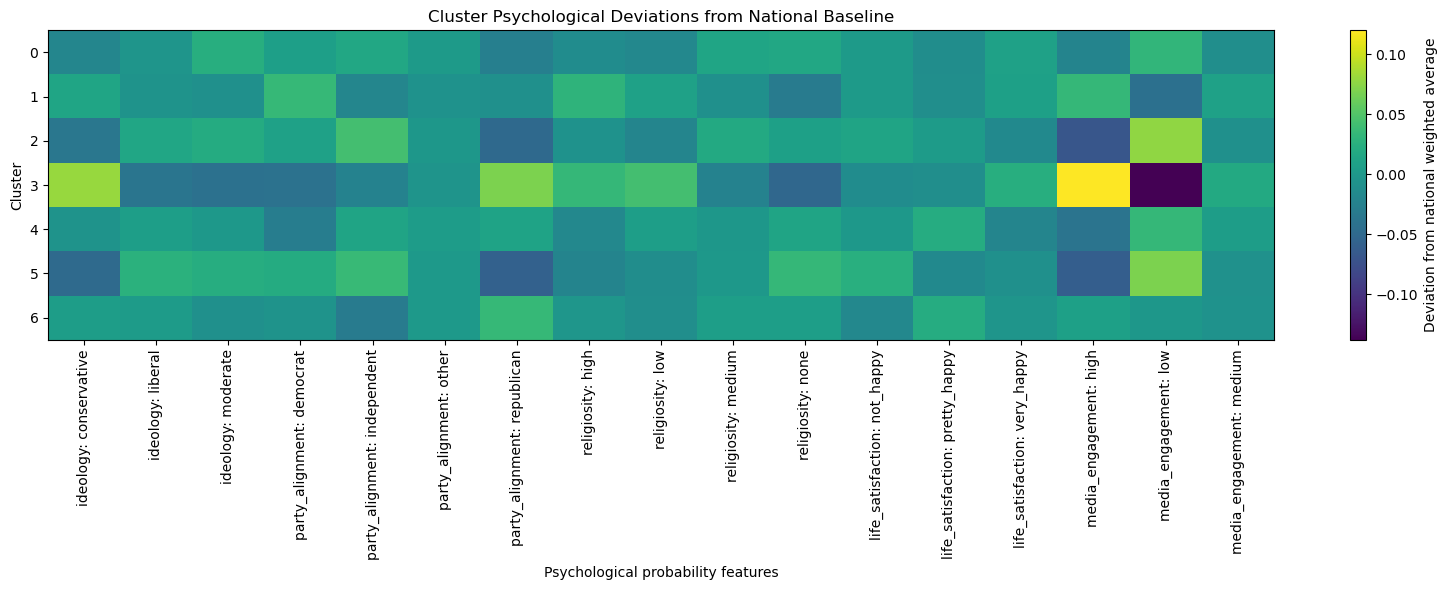

In [19]:
# create cleaner column labels for the heatmap
heatmap_df = cluster_psych_dev.set_index("cluster")[prob_cols].copy()
heatmap_df.columns = [c.replace("__", ": ") for c in heatmap_df.columns]

fig, ax = plt.subplots(figsize=(16, 6))

im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=90)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Cluster Psychological Deviations from National Baseline")
ax.set_xlabel("Psychological probability features")
ax.set_ylabel("Cluster")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Deviation from national weighted average")

plt.tight_layout()
plt.show()

In [20]:
# show strongest positive and negative deviations for each cluster
for cl in heatmap_df.index:
    s = heatmap_df.loc[cl].sort_values()

    print(f"\nCluster {cl}")
    print("Most below baseline:")
    print(s.head(5).round(3))

    print("\nMost above baseline:")
    print(s.tail(5).round(3))


Cluster 0
Most below baseline:
party_alignment: republican   -0.027
media_engagement: high        -0.022
ideology: conservative        -0.020
religiosity: low              -0.017
religiosity: high             -0.013
Name: 0, dtype: float64

Most above baseline:
religiosity: medium             0.014
party_alignment: independent    0.016
religiosity: none               0.017
ideology: moderate              0.024
media_engagement: low           0.032
Name: 0, dtype: float64

Cluster 1
Most below baseline:
media_engagement: low             -0.043
religiosity: none                 -0.031
party_alignment: independent      -0.020
life_satisfaction: pretty_happy   -0.011
religiosity: medium               -0.009
Name: 1, dtype: float64

Most above baseline:
religiosity: low             0.010
ideology: conservative       0.014
religiosity: high            0.029
media_engagement: high       0.034
party_alignment: democrat    0.035
Name: 1, dtype: float64

Cluster 2
Most below baseline:
media_eng

# Psychological Profile Analysis of Structural Clusters

After aggregating the probabilistic psychological traits at the cluster
level, an initial summary table was produced identifying the **dominant
category** for each psychological dimension (ideology, party alignment,
religiosity, life satisfaction, and media engagement).

However, this first view proved **not very informative**. Because the
psychological traits were inferred probabilistically from survey data
(GSS) and then projected onto the synthetic ACS population, the
resulting cluster averages tended to **converge toward the national
baseline distribution**. As a result, most clusters appeared to share
the same dominant categories (e.g., "moderate" ideology, "Democrat"
party alignment, "pretty happy" life satisfaction), masking potentially
meaningful differences between segments.

To reveal the underlying structure, the analysis shifted from examining
**absolute probabilities** to analyzing **deviations from the national
weighted baseline**. The national baseline for each psychological
probability was computed using ACS weights (`pwgtp`), and each
cluster's psychological profile was expressed as the difference between
the cluster-level estimate and the national average.

This transformation highlights **relative behavioral tendencies** within
each structural segment. Positive values indicate that a trait is
**more prevalent in the cluster than in the national population**,
while negative values indicate that it is **less prevalent than
average**. This deviation-based view revealed clearer patterns across
clusters — segments that are relatively more conservative, more
religious, or more engaged with media than the population baseline.

At this stage, the deviations represent **estimated differences derived
from weighted projections**, not direct survey measurements. Because
the synthetic population is large and weighted, even small differences
may appear meaningful. The next step is therefore to assess whether
these deviations are **statistically meaningful relative to sampling
variability**.

To do so, a **weighted bootstrap procedure** is implemented. For each
cluster and psychological trait, rows within the cluster are resampled
with replacement (respecting ACS weights), and the weighted mean is
recomputed across many iterations. This allows the construction of
**confidence intervals around the cluster estimates**, enabling
evaluation of whether observed deviations from the national baseline
fall outside the expected variability of the estimate.

This step helps distinguish **substantive behavioral signals** from
small fluctuations due to sampling noise, strengthening the
interpretability of the psychological cluster profiles.

Note: clusters in this notebook reflect the **adult-only K-Prototypes
k=7 solution** from notebooks 05b/06b. All seven clusters represent
actionable adult population archetypes — no minor segments are present.

In [21]:
# weighted bootstrap for probability columns
def weighted_bootstrap_mean(df_cluster, col, weights_col="pwgtp", n_boot=300):
    
    values = df_cluster[col].values
    weights = df_cluster[weights_col].values
    
    probs = weights / weights.sum()
    
    boot_means = []
    
    n = len(values)
    
    for _ in range(n_boot):
        idx = np.random.choice(n, size=n, replace=True, p=probs)
        boot_means.append(values[idx].mean())   # IMPORTANT: no weights here
        
    return np.percentile(boot_means, [2.5, 97.5])

In [22]:
np.random.seed(42)
cluster_id = 4
col = "ideology__conservative"

df_cluster = df[df["cluster"] == cluster_id]

ci = weighted_bootstrap_mean(df_cluster, col)

cluster_mean = cluster_psych.loc[
    cluster_psych.cluster == cluster_id, col
].values[0]

print("Cluster mean:", cluster_mean)
print("95% CI:", ci)
print("National baseline:", national_psych[col])

Cluster mean: 0.3105602317385769
95% CI: [0.30945675 0.31159074]
National baseline: 0.3166590607270613


In [23]:
# ── Systematic bootstrap CI across all clusters and traits ───────────────────
# For each (cluster, trait) combination, compute 95% CI via weighted bootstrap.
# A deviation is flagged as substantive if the CI does not overlap the
# national baseline — replacing the arbitrary 3% threshold.

np.random.seed(42)

ci_rows = []

for cluster_id in sorted(df["cluster"].unique()):
    df_cluster = df[df["cluster"] == cluster_id]

    for col in prob_cols:
        ci_low, ci_high = weighted_bootstrap_mean(df_cluster, col)
        baseline        = national_psych[col]
        cluster_mean    = cluster_psych.loc[
            cluster_psych["cluster"] == cluster_id, col
        ].values[0]
        deviation       = cluster_mean - baseline

        # substantive = CI does not overlap national baseline
        substantive = not (ci_low <= baseline <= ci_high)

        ci_rows.append({
            "cluster":        cluster_id,
            "trait":          col,
            "cluster_mean":   round(cluster_mean, 4),
            "baseline":       round(baseline, 4),
            "deviation":      round(deviation, 4),
            "ci_low":         round(ci_low, 4),
            "ci_high":        round(ci_high, 4),
            "substantive":    substantive,
        })

ci_df = pd.DataFrame(ci_rows)

# Summary: how many substantive signals per cluster
print("Substantive signals per cluster:")
print(
    ci_df[ci_df["substantive"]]
    .groupby("cluster")["trait"]
    .count()
    .to_string()
)

print(f"\nTotal substantive signals: {ci_df['substantive'].sum()} "
      f"of {len(ci_df)} combinations")

Substantive signals per cluster:
cluster
0    17
1    17
2    17
3    17
4    16
5    16
6    17

Total substantive signals: 117 of 119 combinations


In [33]:
# CI-based cluster psychological signature
# Combined filter: statistically substantive (CI) + practically meaningful (3pp)

ci_signature = ci_df[
    ci_df["substantive"] & (ci_df["deviation"].abs() >= 0.03)
].copy()

ci_signature["trait"]     = ci_signature["trait"].str.replace("__", ": ")
ci_signature["direction"] = ci_signature["deviation"].apply(
    lambda x: "above baseline" if x > 0 else "below baseline"
)
ci_signature["abs_dev"]   = ci_signature["deviation"].abs()

ci_signature = ci_signature.sort_values(
    ["cluster", "abs_dev"], ascending=[True, False]
).drop(columns="abs_dev").reset_index(drop=True)

print(ci_signature.to_string(index=False))

 cluster                        trait  cluster_mean  baseline  deviation  ci_low  ci_high  substantive      direction
       0        media_engagement: low        0.6437    0.6116     0.0322  0.6425   0.6449         True above baseline
       1        media_engagement: low        0.5683    0.6116    -0.0433  0.5669   0.5696         True below baseline
       1    party_alignment: democrat        0.4878    0.4531     0.0347  0.4866   0.4889         True above baseline
       1       media_engagement: high        0.3259    0.2922     0.0336  0.3246   0.3271         True above baseline
       1            religiosity: none        0.2048    0.2354    -0.0306  0.2036   0.2057         True below baseline
       2        media_engagement: low        0.6887    0.6116     0.0771  0.6866   0.6912         True above baseline
       2       media_engagement: high        0.2236    0.2922    -0.0686  0.2215   0.2255         True below baseline
       2  party_alignment: republican        0.2874    0

In [25]:
# Practical significance filter — deviation >= 3 percentage points.
# Applied on top of the CI-based statistical filter above.
# With n=778,466 adults, nearly all deviations are statistically
# distinguishable from baseline (117/119 combinations). The 3pp
# threshold therefore serves as the actionability filter:
# deviations below 3pp are real but too small to drive meaningfully
# different messaging or targeting decisions.

threshold = 0.03

substantive_devs = heatmap_df.where(abs(heatmap_df) >= threshold)
substantive_devs

,ideology: conservative,ideology: liberal,ideology: moderate,party_alignment: democrat,party_alignment: independent,party_alignment: other,party_alignment: republican,religiosity: high,religiosity: low,religiosity: medium,religiosity: none,life_satisfaction: not_happy,life_satisfaction: pretty_happy,life_satisfaction: very_happy,media_engagement: high,media_engagement: low,media_engagement: medium
cluster,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032157,NaN
1,NaN,NaN,NaN,0.034725,NaN,NaN,NaN,NaN,NaN,NaN,-0.030650,NaN,NaN,NaN,0.033647,-0.043296,NaN
2,-0.035495,NaN,NaN,NaN,0.042327,NaN,-0.049606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.068650,0.077116,NaN
3,0.080492,-0.038168,-0.042323,-0.041043,NaN,NaN,0.068899,0.033384,0.042284,NaN,-0.052185,NaN,NaN,NaN,0.119775,-0.138023,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.038656,0.033565,NaN
5,-0.049241,NaN,NaN,NaN,0.036174,NaN,-0.058282,NaN,NaN,NaN,0.033650,NaN,NaN,NaN,-0.060651,0.068629,NaN
6,NaN,NaN,NaN,NaN,-0.031200,NaN,0.034904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Signal counts using practical significance threshold (>= 3pp)
# Compare with CI-based counts above to see where the two filters agree
signal_counts = (abs(heatmap_df) >= threshold).sum(axis=1)

print("Signals per cluster (3pp threshold):")
print(signal_counts.to_string())

Signals per cluster (3pp threshold):
cluster
0     1
1     4
2     5
3    10
4     2
5     6
6     2


In [27]:
# Cluster archetypes (from notebook 06b):
#   0: Diverse Mid-Life Workers
#   1: Older Non-Partnered Adults
#   2: Young Hispanic Working Adults
#   3: Retired Renters
#   4: Mid-Career Homeowners
#   5: Young Non-Owning Singles
#   6: Established Mid-Career Homeowners

for cluster in heatmap_df.index:
    s = heatmap_df.loc[cluster]
    strong = s[abs(s) >= threshold].sort_values()
    print(f"\nCluster {cluster}")
    print(strong.round(3))


Cluster 0
media_engagement: low    0.032
Name: 0, dtype: float64

Cluster 1
media_engagement: low       -0.043
religiosity: none           -0.031
media_engagement: high       0.034
party_alignment: democrat    0.035
Name: 1, dtype: float64

Cluster 2
media_engagement: high         -0.069
party_alignment: republican    -0.050
ideology: conservative         -0.035
party_alignment: independent    0.042
media_engagement: low           0.077
Name: 2, dtype: float64

Cluster 3
media_engagement: low         -0.138
religiosity: none             -0.052
ideology: moderate            -0.042
party_alignment: democrat     -0.041
ideology: liberal             -0.038
religiosity: high              0.033
religiosity: low               0.042
party_alignment: republican    0.069
ideology: conservative         0.080
media_engagement: high         0.120
Name: 3, dtype: float64

Cluster 4
media_engagement: high   -0.039
media_engagement: low     0.034
Name: 4, dtype: float64

Cluster 5
media_engagement: h

In [28]:
# Cluster psychological signature table — practical significance filter (>= 3pp)
# This uses the fixed threshold only. See ci_signature above for the
# combined CI + threshold filter which is the recommended output.

threshold = 0.03

rows = []

for cluster in heatmap_df.index:
    s     = heatmap_df.loc[cluster]
    strong = s[abs(s) >= threshold].sort_values()

    for trait, dev in strong.items():
        rows.append({
            "cluster":   cluster,
            "trait":     trait.replace("__", ": "),
            "deviation": round(dev, 3),
            "direction": "above baseline" if dev > 0 else "below baseline"
        })

cluster_signature_threshold = pd.DataFrame(rows)
cluster_signature_threshold.sort_values(
    ["cluster", "deviation"], inplace=True
)
cluster_signature_threshold

,cluster,trait,deviation,direction
0,0,media_engagement: low,0.032,above baseline
1,1,media_engagement: low,-0.043,below baseline
2,1,religiosity: none,-0.031,below baseline
3,1,media_engagement: high,0.034,above baseline
4,1,party_alignment: democrat,0.035,above baseline
5,2,media_engagement: high,-0.069,below baseline
6,2,party_alignment: republican,-0.050,below baseline
7,2,ideology: conservative,-0.035,below baseline
8,2,party_alignment: independent,0.042,above baseline
9,2,media_engagement: low,0.077,above baseline


In [29]:
cluster_signature_threshold["abs_dev"] = cluster_signature_threshold["deviation"].abs()

cluster_signature_threshold.sort_values(
    ["cluster", "abs_dev"], ascending=[True, False], inplace=True
)

cluster_signature_threshold.drop(columns="abs_dev", inplace=True)
cluster_signature_threshold

,cluster,trait,deviation,direction
0,0,media_engagement: low,0.032,above baseline
1,1,media_engagement: low,-0.043,below baseline
4,1,party_alignment: democrat,0.035,above baseline
3,1,media_engagement: high,0.034,above baseline
2,1,religiosity: none,-0.031,below baseline
9,2,media_engagement: low,0.077,above baseline
5,2,media_engagement: high,-0.069,below baseline
6,2,party_alignment: republican,-0.050,below baseline
8,2,party_alignment: independent,0.042,above baseline
7,2,ideology: conservative,-0.035,below baseline


In [30]:
# Save full cluster psychological profile table
output_path = MODELS_DIR / "08_mk_cluster_psych_profiles.parquet"

cluster_psych.to_parquet(output_path, index=False)
print(f"✓ Saved: {output_path}")

✓ Saved: /Users/marcomagnolo/Projects/Market_Kinetics/data/societal_models/08_mk_cluster_psych_profiles.parquet


In [31]:
# Save cluster psychological signatures
# Primary output: CI + threshold combined filter (actionable signals)
# Secondary output: threshold-only filter (for reference)

output_path_primary = MODELS_DIR / "08_mk_cluster_psychological_signatures.parquet"
output_path_threshold = MODELS_DIR / "08_mk_cluster_psychological_signatures_threshold.parquet"

ci_signature.to_parquet(output_path_primary, index=False)
cluster_signature_threshold.to_parquet(output_path_threshold, index=False)

print(f"✓ Saved primary (CI + threshold): {output_path_primary.name}")
print(f"  Shape: {ci_signature.shape}")
print(f"✓ Saved reference (threshold only): {output_path_threshold.name}")
print(f"  Shape: {cluster_signature_threshold.shape}")

✓ Saved primary (CI + threshold): 08_mk_cluster_psychological_signatures.parquet
  Shape: (30, 9)
✓ Saved reference (threshold only): 08_mk_cluster_psychological_signatures_threshold.parquet
  Shape: (30, 4)


In [32]:
# Print cluster psychological signatures in grouped form
# Using CI + threshold combined filter (actionable signals)

archetype_names = {
    0: "Diverse Mid-Life Workers",
    1: "Older Non-Partnered Adults",
    2: "Young Hispanic Working Adults",
    3: "Retired Renters",
    4: "Mid-Career Homeowners",
    5: "Young Non-Owning Singles",
    6: "Established Mid-Career Homeowners",
}

for cluster in sorted(ci_signature["cluster"].unique()):

    df_c  = ci_signature[ci_signature["cluster"] == cluster]
    above = df_c[df_c["direction"] == "above baseline"].sort_values("deviation", ascending=False)
    below = df_c[df_c["direction"] == "below baseline"].sort_values("deviation")

    print(f"\nCluster {cluster} — {archetype_names.get(cluster, '')}")

    if len(above) > 0:
        print("  Above baseline:")
        for _, r in above.iterrows():
            print(f"    {r['trait']}  (+{r['deviation']:.3f})")

    if len(below) > 0:
        print("  Below baseline:")
        for _, r in below.iterrows():
            print(f"    {r['trait']}  ({r['deviation']:.3f})")


Cluster 0 — Diverse Mid-Life Workers
  Above baseline:
    media_engagement: low  (+0.032)

Cluster 1 — Older Non-Partnered Adults
  Above baseline:
    party_alignment: democrat  (+0.035)
    media_engagement: high  (+0.034)
  Below baseline:
    media_engagement: low  (-0.043)
    religiosity: none  (-0.031)

Cluster 2 — Young Hispanic Working Adults
  Above baseline:
    media_engagement: low  (+0.077)
    party_alignment: independent  (+0.042)
  Below baseline:
    media_engagement: high  (-0.069)
    party_alignment: republican  (-0.050)
    ideology: conservative  (-0.035)

Cluster 3 — Retired Renters
  Above baseline:
    media_engagement: high  (+0.120)
    ideology: conservative  (+0.081)
    party_alignment: republican  (+0.069)
    religiosity: low  (+0.042)
    religiosity: high  (+0.033)
  Below baseline:
    media_engagement: low  (-0.138)
    religiosity: none  (-0.052)
    ideology: moderate  (-0.042)
    party_alignment: democrat  (-0.041)
    ideology: liberal  (-0.0

# Cluster-Level Psychological Profiles — Results and Interpretation

This notebook enriched the adult-only structural population clusters
with psychological characteristics inferred from survey data. The goal
was to transform demographic segments into behaviorally interpretable
population archetypes that can support downstream audience analysis,
messaging strategy, and influence modeling.

---

## Methodology Summary

### 1. Individual-Level Psychological Projection
Psychological traits (ideology, party alignment, religiosity, life
satisfaction, and media engagement) were inferred in notebook 07 using
**General Social Survey (GSS)** data projected onto the ACS structural
population via demographic conditioning and hierarchical fallback.

### 2. Cluster-Level Aggregation
Individual-level probabilities were aggregated to the cluster level
using ACS person weights (`pwgtp`), producing a weighted psychological
probability distribution for each trait dimension per cluster.

### 3. Baseline Deviation Analysis
Raw cluster averages converge toward the national distribution due to
the probabilistic projection methodology. To reveal meaningful
differences, cluster-level estimates were compared to the national
weighted baseline:

`cluster deviation = cluster probability − national probability`

### 4. Statistical and Practical Significance Filters
Two filters were applied in sequence:

**Statistical filter (bootstrap CI):** A weighted bootstrap procedure
(n=300 iterations) computed 95% confidence intervals for each
cluster-trait combination. A deviation is statistically substantive
if the CI does not overlap the national baseline.

**Practical significance filter (3pp threshold):** A minimum threshold
of 3 percentage points was applied as an actionability filter. Only
deviations ≥ 3pp drive meaningfully different messaging or targeting
decisions.

The combined filter (CI + 3pp) defines the **actionable psychological
signals** reported below.

---

## Psychological Signatures of the Clusters

### Cluster 0 — Diverse Mid-Life Workers
Dominant signals: low media engagement above baseline (+0.032).

Portrait: psychologically close to the national average with a single
meaningful signal — slightly elevated low media engagement. The most
neutral cluster psychologically. Consistent with busy mid-life working
adults with limited time for news consumption and no strong ideological
or partisan lean.

---

### Cluster 1 — Older Non-Partnered Adults
Dominant signals: low media engagement below baseline (-0.043),
Democrat above baseline (+0.035), high media engagement above baseline
(+0.034), religiosity__none below baseline (-0.031).

Portrait: engaged, religious, Democrat-leaning older adults. Higher
media consumption than average, with a meaningful religious signal and
a clear partisan lean toward the Democratic party. Consistent with
older non-partnered adults — many of whom are widowed women — with
strong community and institutional ties.

---

### Cluster 2 — Young Hispanic Working Adults
Dominant signals: low media engagement above baseline (+0.077),
Independent above baseline (+0.042), high media engagement below
baseline (-0.069), Republican below baseline (-0.050), conservative
below baseline (-0.035).

Portrait: politically independent, non-conservative, low media
engagement. The strongest independence signal of any cluster alongside
cluster 5. Consistent with younger Hispanic working adults with weak
partisan attachment and limited news consumption habits.

---

### Cluster 3 — Retired Renters
Dominant signals: high media engagement far above baseline (+0.120),
conservative above baseline (+0.081), Republican above baseline
(+0.069), low media engagement far below baseline (-0.138),
religiosity__none below baseline (-0.052), moderate below baseline
(-0.042), Democrat below baseline (-0.041), liberal below baseline
(-0.038), religiosity__low above baseline (+0.042),
religiosity__high above baseline (+0.033).

Portrait: the most psychologically distinctive cluster by a wide
margin. Heavily conservative, strongly Republican, high media
consumers, and religious. Almost no secular or low-media adults.
Consistent with older retired White men in rental housing with
entrenched partisan identity, daily news habits, and active faith
community ties. The strongest ideological signal in the entire
segmentation.

---

### Cluster 4 — Mid-Career Homeowners
Dominant signals: low media engagement above baseline (+0.034),
high media engagement below baseline (-0.039).

Portrait: psychologically close to the national average, defined
primarily by below-average media engagement. No meaningful ideological,
partisan, or religiosity signals. Consistent with busy mid-career
homeowners focused on work and family obligations with limited media
consumption.

---

### Cluster 5 — Young Non-Owning Singles
Dominant signals: low media engagement above baseline (+0.069),
Independent above baseline (+0.036), religiosity__none above baseline
(+0.034), high media engagement below baseline (-0.061), Republican
below baseline (-0.058), conservative below baseline (-0.049).

Portrait: secular, independent, non-conservative, low media engagement.
The most secular cluster and one of the strongest independent signals.
Consistent with young never-married adults with weak institutional and
partisan ties. Mirrors cluster 2 in political orientation but with a
stronger secular signal.

---

### Cluster 6 — Established Mid-Career Homeowners
Dominant signals: Republican above baseline (+0.035), Independent
below baseline (-0.031).

Portrait: mildly Republican-leaning with a clear partisan commitment —
the below-baseline independent signal suggests these adults have
settled partisan identities rather than floating between parties.
Otherwise psychologically close to the national average. Consistent
with established mid-career homeowners with stable life circumstances
and conventional partisan alignment.

---

## Output Artifacts

- `08_mk_cluster_psych_profiles.parquet` — full cluster psychological
  probability table
- `08_mk_cluster_psychological_signatures.parquet` — actionable
  signals (CI + 3pp combined filter), primary output
- `08_mk_cluster_psychological_signatures_threshold.parquet` —
  threshold-only signals, reference output